In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [2]:
print("Shape:", df.shape)
df.info()

Shape: (5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [3]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [4]:
print(df.isnull().sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [5]:
df = df.drop(columns=['Address'])
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


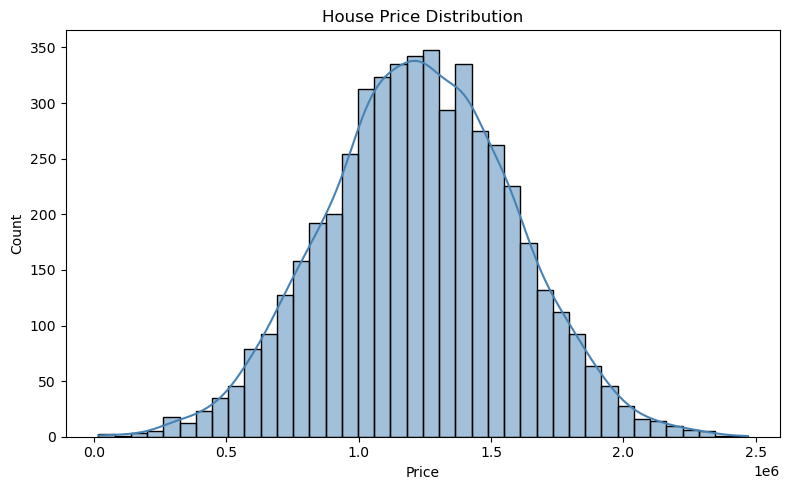

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=40, kde=True, color='steelblue')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

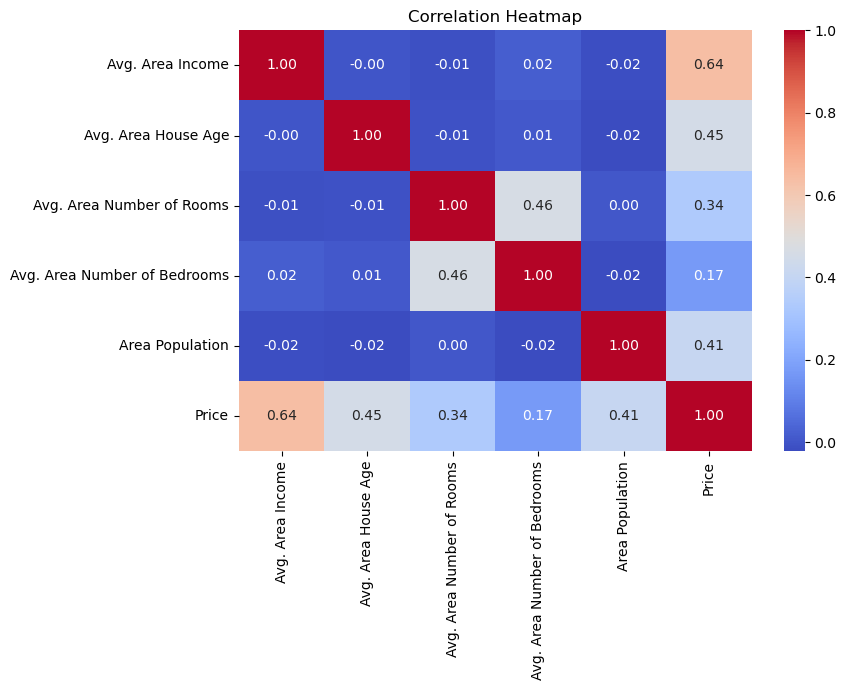

In [7]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

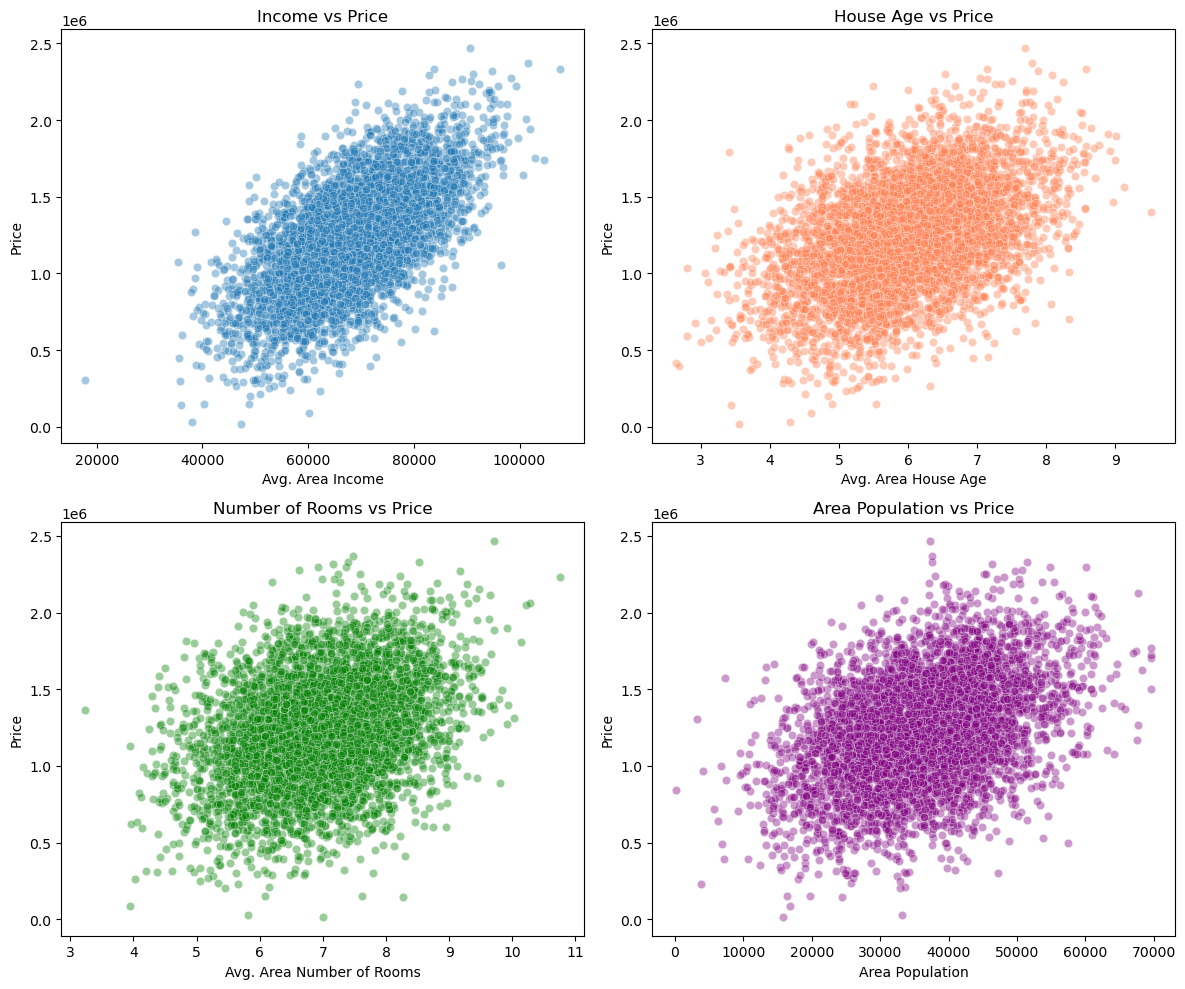

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.scatterplot(data=df, x='Avg. Area Income', y='Price', ax=axes[0,0], alpha=0.4)
axes[0,0].set_title('Income vs Price')

sns.scatterplot(data=df, x='Avg. Area House Age', y='Price', ax=axes[0,1], alpha=0.4, color='coral')
axes[0,1].set_title('House Age vs Price')

sns.scatterplot(data=df, x='Avg. Area Number of Rooms', y='Price', ax=axes[1,0], alpha=0.4, color='green')
axes[1,0].set_title('Number of Rooms vs Price')

sns.scatterplot(data=df, x='Area Population', y='Price', ax=axes[1,1], alpha=0.4, color='purple')
axes[1,1].set_title('Area Population vs Price')

plt.tight_layout()
plt.show()

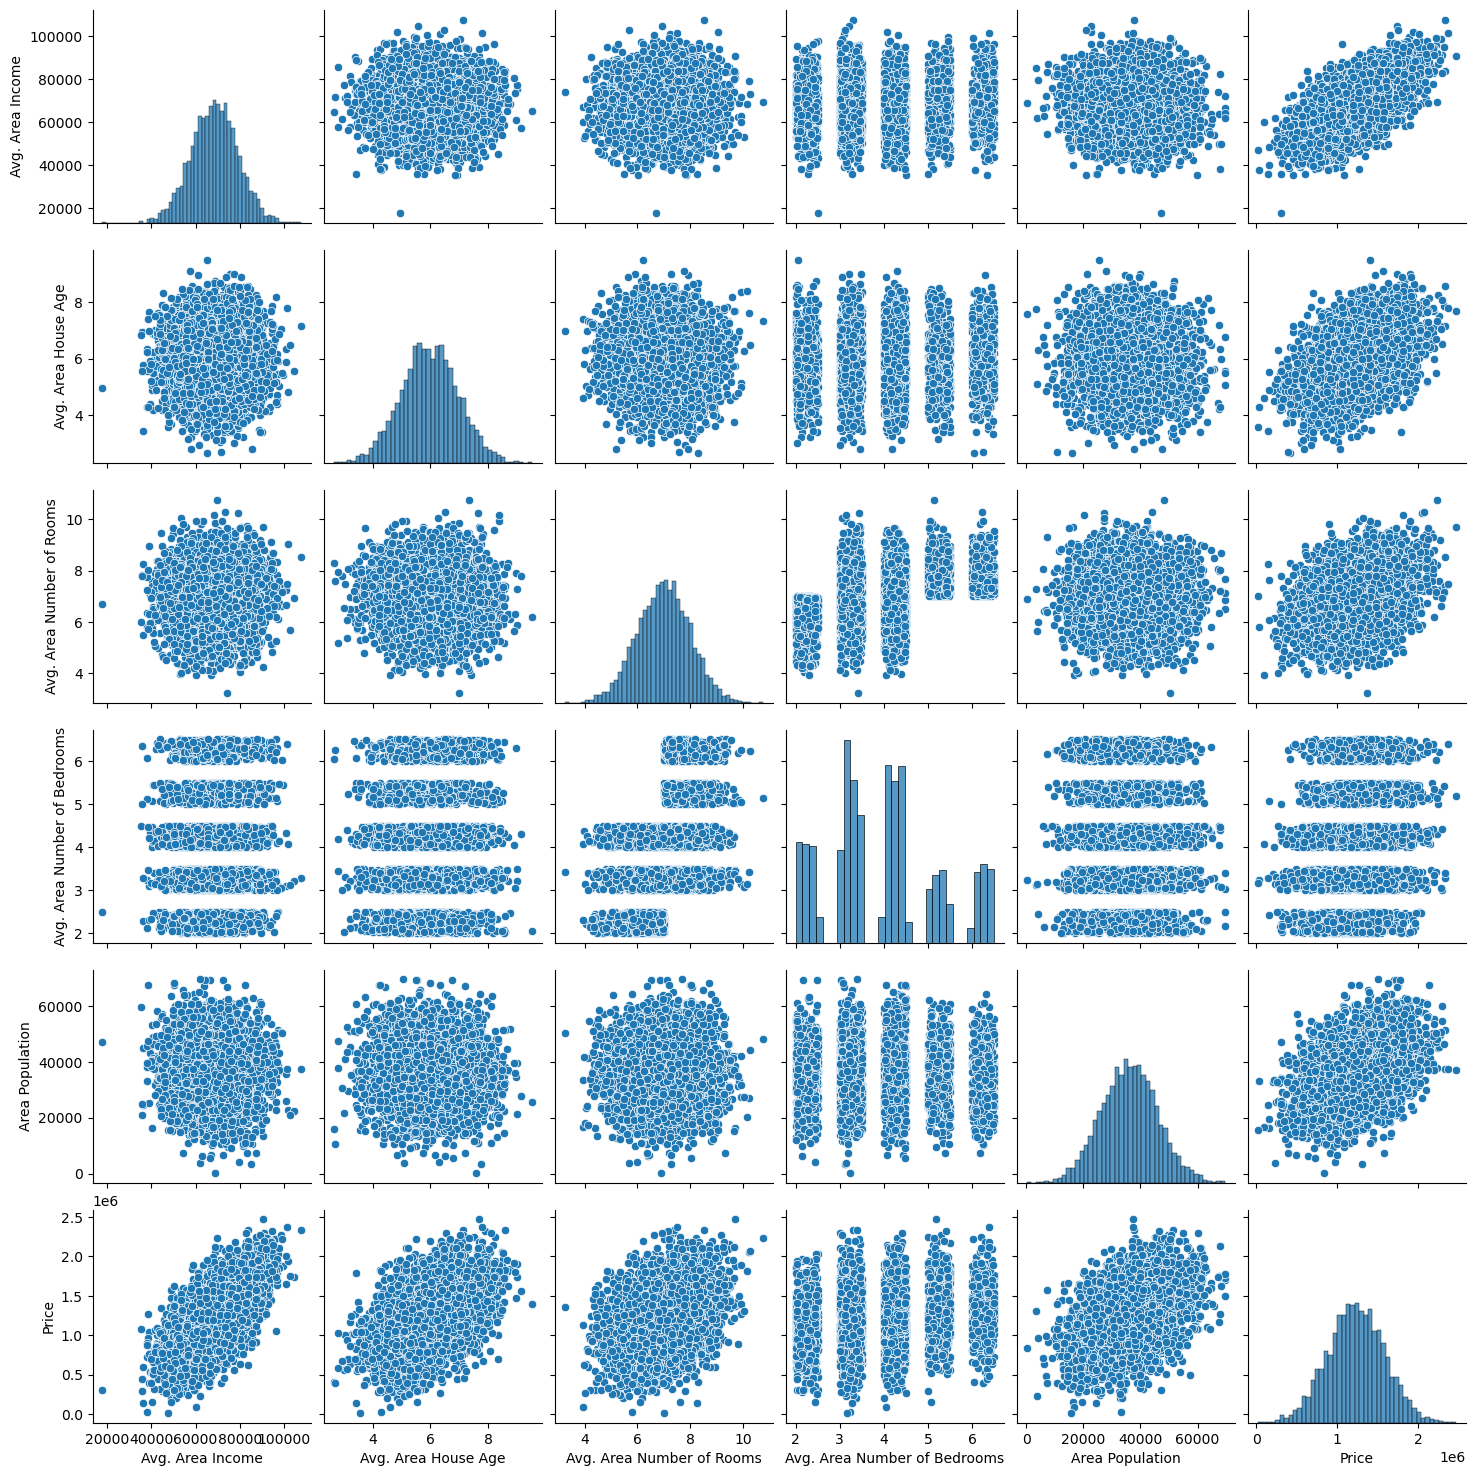

In [10]:
sns.pairplot(df)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4000, 5)
Test shape: (1000, 5)


In [15]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

lin_preds = lin_model.predict(X_test_scaled)
print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R² Score: {r2:.4f}\n")

evaluate("Linear Regression", y_test, lin_preds)
evaluate("Random Forest", y_test, rf_preds)

=== Linear Regression ===
MAE:  80,879.10
RMSE: 100,444.06
R² Score: 0.9180

=== Random Forest ===
MAE:  94,021.49
RMSE: 119,893.01
R² Score: 0.8832



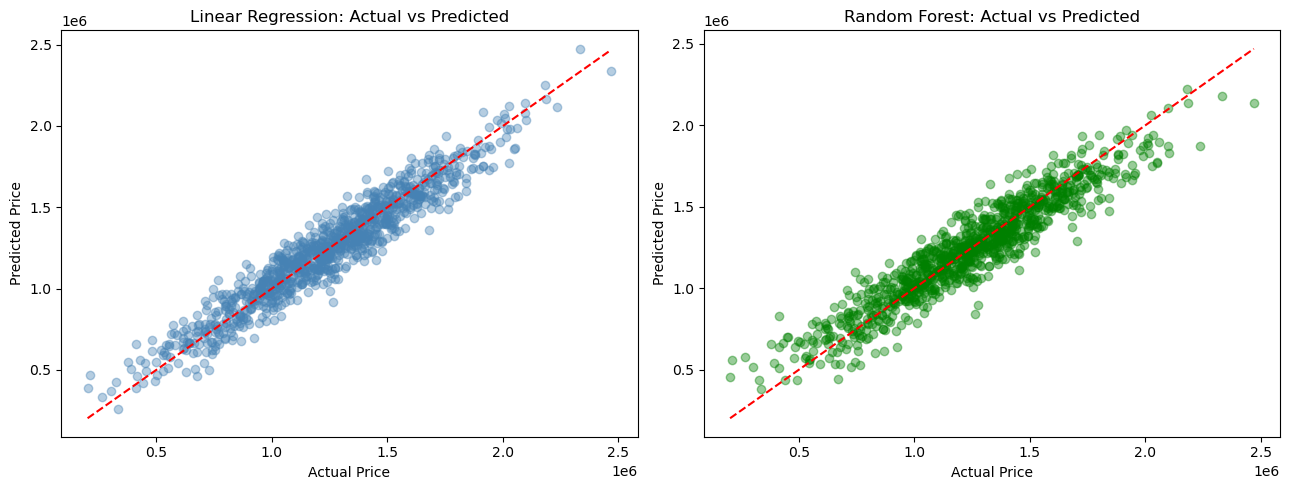

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(y_test, lin_preds, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(y_test, rf_preds, alpha=0.4, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

Linear Regression Coefficients:
 Avg. Area Income                231741.876652
Avg. Area House Age             163580.776566
Area Population                 152235.900097
Avg. Area Number of Rooms       120724.771387
Avg. Area Number of Bedrooms      2992.449135
dtype: float64


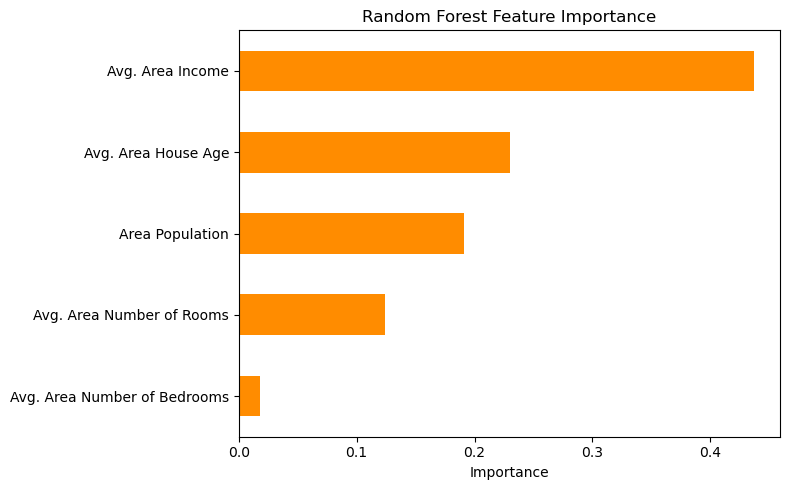

In [19]:
coefficients = pd.Series(lin_model.coef_, index=X.columns).sort_values(ascending=False)
print("Linear Regression Coefficients:\n", coefficients)

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='darkorange')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
df.to_csv('cleaned_house_prices.csv', index=False)
print("Cleaned dataset saved as 'cleaned_house_prices.csv'")

Cleaned dataset saved as 'cleaned_house_prices.csv'
